# Change Properties of the target

Once you have loaded a target and potentially fine tuned the detector or spectrograph setup, you may have to see the effect of changing (simular) targets. 

This is simple using `set_properties()` which enables you to change any properties of the target

## Type Ia Supernovae

Let's load a redshift=1.0 SN Ia with a c=0.3 and and x1=0.2, setup the instrument to reach a signal to noise of 20.

In [3]:
import slicersim

In [5]:
lazuli_snia = slicersim.LazuliSN(redshift=1.0, c=0.3, x1=0.2)
_ = lazuli_snia.setup_to_snr(20, lbda_range=[6000, 7000], frame="rest")

The target values are what was expected when triggering the target.

Yet, in reality, the target properties differ. The actual redshift is 1.05, the c=0.2 and x1=-2

In [7]:
lazuli_snia.set_properties(redshift=1.05, c=0.2, x1=-2.)

In [11]:
lbda, flux, variance = lazuli_snia.get_spectrum()
snr_spec = flux/np.sqrt(variance)

let's now see the resulting signal to noise ratio

In [14]:
lbda_range=[6000, 7000]
redshift = 1.05
flag_in = (lbda>6000*(1+redshift)) & (lbda<7000*(1+redshift))
np.mean(snr_spec[flag_in]) # slightly smaller

17.10050316702408

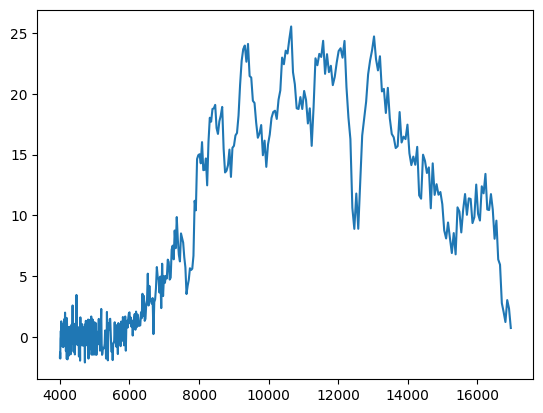

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(lbda, snr_spec)

# Any Spectrum or CalSpec

For generic target (loaded given their spectral flux) the some things you can change is the observed magnitude in a given band. 

This band has to be a [sncosmo band](https://sncosmo.readthedocs.io/en/stable/bandpass-list.html)

In [17]:
lazuli_star = slicersim.LazuliCalSpec("gd71")

In [18]:
lazuli_star.set_properties(mag=22, band="lssti")

In [40]:
lazuli_star.set_properties(mag=22, band="lssti")
lbda, flux_22, variance_22 = lazuli_star.get_spectrum(unit="flambda", incl_error=False)

lazuli_star.set_properties(mag=21, band="lssti")
lbda, flux_21, variance_21 = lazuli_star.get_spectrum(unit="flambda", incl_error=False)

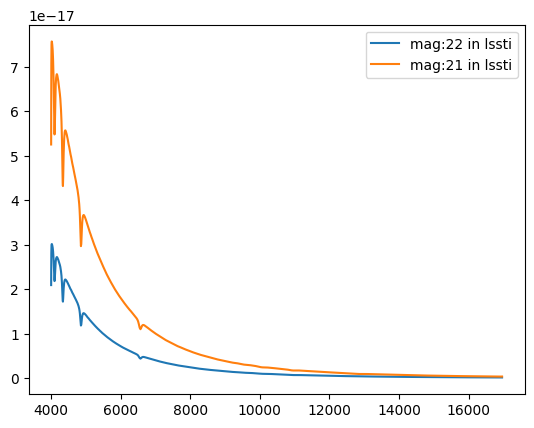

In [44]:
fig, ax = plt.subplots()
ax.plot(lbda, flux_22, label="mag:22 in lssti")
ax.plot(lbda, flux_21, label="mag:21 in lssti")
ax.legend()